# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("unit2_ppt7_superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year
print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

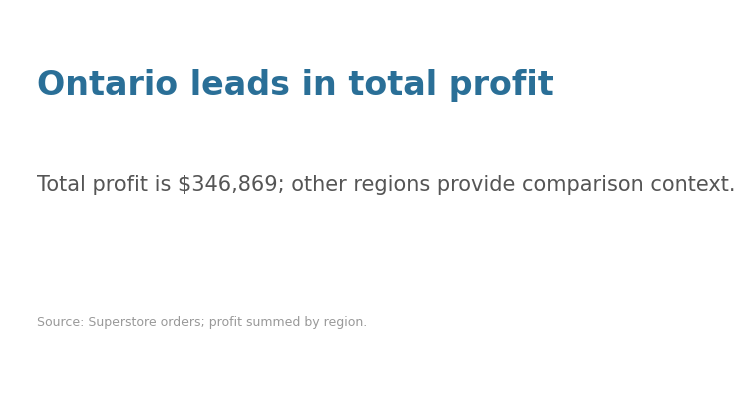

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()
best_profit = region_totals.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")
ax.text(0.05, 0.78, f"{best_region} leads in total profit",
        fontsize=24, fontweight="bold", color="#2A6F97", transform=ax.transAxes)
ax.text(0.05, 0.53,
        f"Total profit is ${best_profit:,.0f}; other regions provide comparison context.",
        fontsize=15, fontweight="medium", color="#555555", transform=ax.transAxes)
ax.text(0.05, 0.18, "Source: Superstore orders; profit summed by region.",
        fontsize=9, fontweight="normal", color="#999999", transform=ax.transAxes)
plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

The primary headline should dominate first, followed by the supporting sentence and then the source note. In a two-second glance, the viewer should take away which region had the highest total profit.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

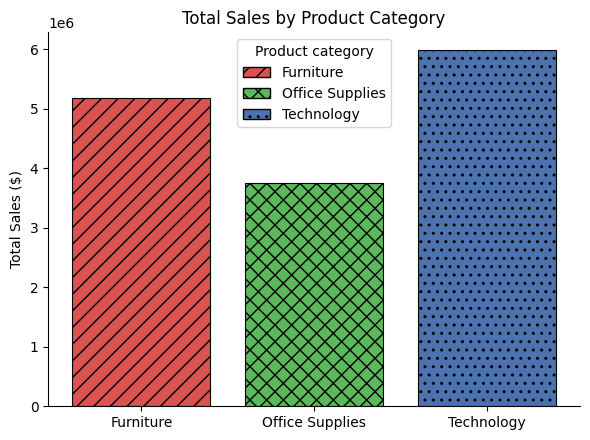

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = []
for cat in cat_sales.index:
    bar = ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat],
                 edgecolor="black", linewidth=0.8, label=cat)
    bars.append(bar[0])

legend_handles = [
    mpatches.Patch(facecolor=colors[cat], edgecolor="black", hatch=hatches[cat], label=cat)
    for cat in cat_sales.index
]
ax.legend(handles=legend_handles, title="Product category")
ax.set_title("Total Sales by Product Category")
ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

Without hatch patterns, the chart can fail for viewers with color-vision deficiencies and for anyone viewing a grayscale printout. Encoding categories with both color and pattern provides a redundant cue.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

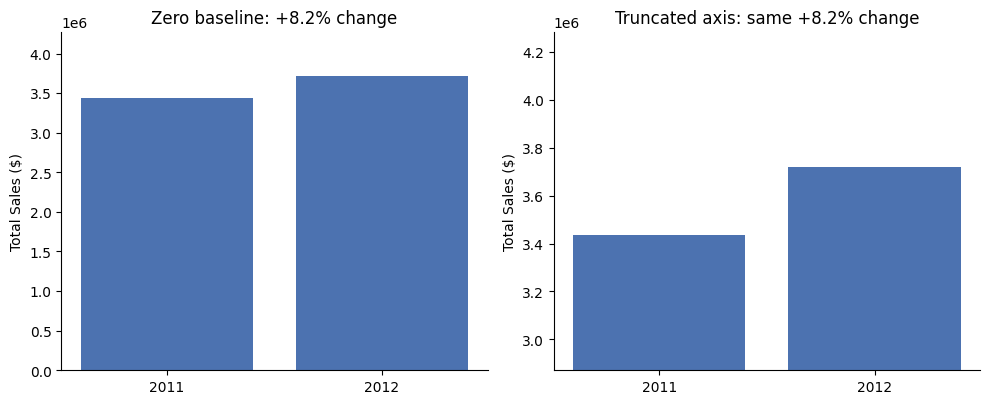

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = float(yearly_sales.loc[y1]), float(yearly_sales.loc[y2])
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_title(f"Zero baseline: {pct_change:+.1f}% change")
axes[0].set_ylabel("Total Sales ($)")

axes[1].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
pad = max(abs(v2-v1) * 2, max(v1, v2) * 0.02)
axes[1].set_ylim(min(v1, v2)-pad, max(v1, v2)+pad)
axes[1].set_title(f"Truncated axis: same {pct_change:+.1f}% change")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()
print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

I would flag the truncated-axis panel if it appeared alone because the narrow range magnifies the visual difference between the two years. The zero-baseline panel gives a more proportionate impression of the actual percentage change.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales were $3,719,964 in 2012.
INTERPRETIVE: Sales increased by 8.2% from 2011 to 2012; this may reflect several factors, and further evidence is needed to identify the cause.


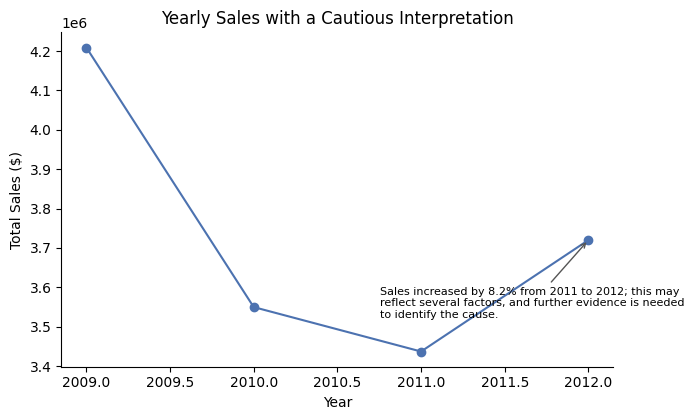

In [5]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"
descriptive_version = (
    f"Sales were ${yearly_sales.iloc[-1]:,.0f} in {yearly_sales.index[-1]}."
)
interpretive_version = (
    f"Sales increased by {pct_change:.1f}% from {y1} to {y2}; "
    "this may reflect several factors, and further evidence is needed to identify the cause."
)

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.annotate(interpretive_version,
            xy=(yearly_sales.index[-1], yearly_sales.iloc[-1]),
            xytext=(-150, -55), textcoords="offset points",
            ha="left", fontsize=8, wrap=True,
            arrowprops=dict(arrowstyle="->", color="#555555"))
ax.set_title("Yearly Sales with a Cautious Interpretation")
ax.set_xlabel("Year"); ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

A descriptive rewrite reports the observed sales value without explaining why it happened. An interpretive rewrite can suggest a plausible explanation, but it must be hedged and should not claim that the chart proves causation.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

I consider correcting the axis exaggeration in Task 3 the most urgent fix because a misleading headline chart can make a small change appear much larger than it really is. The Ethical Visualization Audit asks whether the scale communicates magnitude appropriately, which directly applies to the truncated-axis version in Task 3. Task 3 shows that changing the axis range can create a very different visual impression even though the underlying data is unchanged. I would recommend adding a mandatory visualization review checklist before publication, including checks for axis scale, uncertainty, data selection, and annotation wording. This second review would help prevent similar issues from recurring in future reports.